[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1aKgozj5Y-VrcZfoHZuIrbtyltDS3pueA?usp=sharing)

# **EM2050-Apr2026 : Computational Methods**

# **Practical 1**

# **E/22/194**

## **Tasks**


### **1.**

**a.**

**Sketch the configuration**

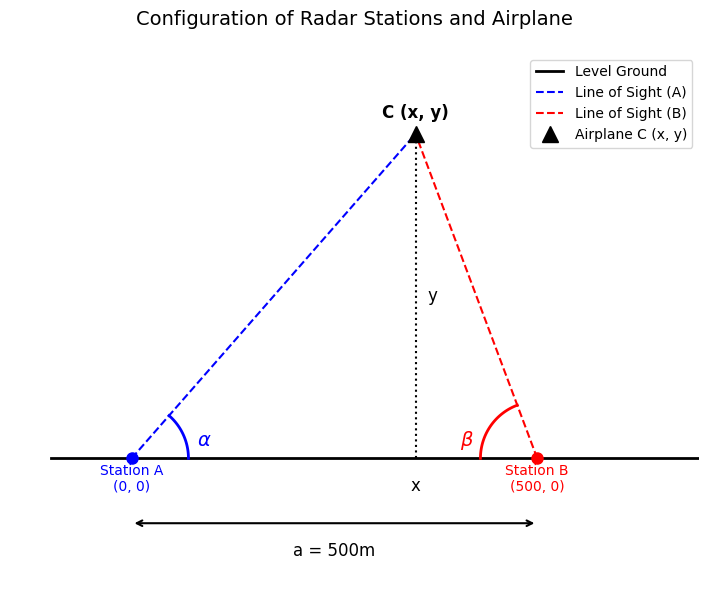

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the known parameters and arbitrary plane coordinates for the sketch
a_distance = 500  # Horizontal distance between stations
A = (0, 0)        # Station A at origin
B = (a_distance, 0) # Station B at x = 500
C = (350, 400)    # Arbitrary airplane position (x, y)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# 2. Draw the level ground
ax.plot([-100, 700], [0, 0], 'k-', lw=2, label='Level Ground')

# 3. Draw lines of sight from stations to the airplane
ax.plot([A[0], C[0]], [A[1], C[1]], 'b--', lw=1.5, label='Line of Sight (A)')
ax.plot([B[0], C[0]], [B[1], C[1]], 'r--', lw=1.5, label='Line of Sight (B)')

# 4. Plot the stations and the airplane
ax.plot(A[0], A[1], 'bo', markersize=8)
ax.plot(B[0], B[1], 'ro', markersize=8)
ax.plot(C[0], C[1], 'k^', markersize=12, label='Airplane C (x, y)')

# 5. Add textual labels for the points
ax.text(A[0], A[1] - 40, 'Station A\n(0, 0)', ha='center', color='blue', fontsize=10)
ax.text(B[0], B[1] - 40, f'Station B\n({a_distance}, 0)', ha='center', color='red', fontsize=10)
ax.text(C[0], C[1] + 20, 'C (x, y)', ha='center', fontsize=12, fontweight='bold')

# 6. Draw and label the horizontal distance 'a'
ax.annotate('', xy=(A[0], -80), xytext=(B[0], -80), arrowprops=dict(arrowstyle='<->', lw=1.5))
ax.text(a_distance / 2, -120, 'a = 500m', ha='center', fontsize=12)

# 7. Draw the projection of the plane to the ground (x, y coordinates)
ax.plot([C[0], C[0]], [0, C[1]], 'k:', lw=1.5)
ax.text(C[0], -40, 'x', ha='center', fontsize=12)
ax.text(C[0] + 15, C[1] / 2, 'y', va='center', fontsize=12)

# 8. Draw angle arcs for alpha and beta
# Arc for Alpha (Angle from Station A)
theta_a = np.linspace(0, np.arctan2(C[1] - A[1], C[0] - A[0]), 100)
r_a = 70
ax.plot(A[0] + r_a * np.cos(theta_a), A[1] + r_a * np.sin(theta_a), 'b-', lw=2)
ax.text(A[0] + r_a + 10, A[1] + 15, r'$\alpha$', color='blue', fontsize=14, fontweight='bold')

# Arc for Beta (Angle from Station B)
# Note: Based on the coordinate formula, beta is typically measured from the horizontal plane
theta_b = np.linspace(np.pi, np.arctan2(C[1] - B[1], C[0] - B[0]), 100)
r_b = 70
ax.plot(B[0] + r_b * np.cos(theta_b), B[1] + r_b * np.sin(theta_b), 'r-', lw=2)
ax.text(B[0] - r_b - 25, B[1] + 15, r'$\beta$', color='red', fontsize=14, fontweight='bold')

# 9. Clean up plot aesthetics
ax.set_aspect('equal')
ax.set_xlim(-150, 700)
ax.set_ylim(-150, 500)
ax.axis('off') # Hide the default grid and axes for a cleaner sketch

plt.title('Configuration of Radar Stations and Airplane', fontsize=14, pad=20)
plt.legend(loc='upper right')
plt.tight_layout()

# Render the plot
plt.show()

**b.**

**Explaining**

$$x = \frac{a \tan \beta}{\tan \beta - \tan \alpha}$$

$$y = \frac{a \tan \beta \tan \alpha}{\tan \beta - \tan \alpha}$$

If  $\tan \beta - \tan \alpha = 0$

$$x = \frac{a \tan \beta}{0} = Undefined $$

$$y = \frac{a \tan \beta \tan \alpha}{0} = Undefined $$

Because of it the coordinate system fails and $x, y$ cannot be resolved

or

Assume the condition fails then,

$$\tan \beta - \tan \alpha = 0 \implies \tan \beta = \tan \alpha \implies \beta = \alpha$$
From above sketch

At station A:
 $$y = x \tan \alpha$$

At station B :

$$y = (x - a) \tan \beta$$

if  $\beta = \alpha$  $$y = (x - a) \tan \alpha$$

Since both lines have the exact same slope ($m = \tan \alpha$) but different intercepts, they are strictly parallel.

Parallel lines never intersect, meaning there is no singular coordinate point $(x,y)$ to represent the airplane

Since  $$\tan \beta - \tan \alpha \neq 0$$

### **2.**

**c.**

**Airplane’s speed**



 The airplane is decelerating ($v'(t) < 0$)

 Because


The angular velocity $\omega_\alpha \approx \frac{\Delta \alpha}{\Delta t}$ drops rapidly

   At $t=7 \to 8$
   $$\omega_\alpha  = 0.5^\circ/\text{s}$$


   At $t=13 \to 14$
   
   $$\omega_\alpha  = 0.2^\circ/\text{s}$$

This is a $60\%$ reduction in angular speed over just 6 seconds.


Because the angular speed drops so drastically the airplane's actual physical linear speed must be decreasing.

### **3.**

**d.**

 **Angle data**

In [17]:
import numpy as np
import os

data = np.array([
    [7, 20.0, 45.0],
    [8, 20.5, 45.4],
    [9, 21.0, 45.8],
    [10, 21.4, 46.2],
    [11, 21.8, 46.6],
    [12, 22.1, 47.0],
    [13, 22.3, 47.3],
    [14, 22.5, 47.6],
])

np.save("plane.npy", data)


**Convert the angles from degrees to radians**

In [12]:
import numpy as np
import pandas as pd

# 1. Load the saved numpy array
data = np.load('plane.npy')

# 2. Extract the individual columns
t = data[:, 0]
alpha_deg = data[:, 1]
beta_deg = data[:, 2]

# 3. Convert the angles from degrees to radians
alpha = np.deg2rad(alpha_deg)
beta = np.deg2rad(beta_deg)

# 4. Create a pandas DataFrame to format the output as a table
df = pd.DataFrame({
    "Time (s)": t.astype(int),
    "Alpha (deg)": alpha_deg,
    "Alpha (rad)": np.round(alpha, 4),
    "Beta (deg)": beta_deg,
    "Beta (rad)": np.round(beta, 4)
})

# 5. Print the converted angle data
print(df.to_string(index=False))

 Time (s)  Alpha (deg)  Alpha (rad)  Beta (deg)  Beta (rad)
        7         20.0       0.3491        45.0      0.7854
        8         20.5       0.3578        45.4      0.7924
        9         21.0       0.3665        45.8      0.7994
       10         21.4       0.3735        46.2      0.8063
       11         21.8       0.3805        46.6      0.8133
       12         22.1       0.3857        47.0      0.8203
       13         22.3       0.3892        47.3      0.8255
       14         22.5       0.3927        47.6      0.8308


**e.**

**Computing  the coordinates**

In [13]:
import numpy as np
import pandas as pd

# 1. Define the known horizontal distance 'a' between stations
a = 500

# 2. Calculate x(t) and y(t)
x = (a * np.tan(beta)) / (np.tan(beta) - np.tan(alpha))
y = (a * np.tan(beta) * np.tan(alpha)) / (np.tan(beta) - np.tan(alpha))

# 4. Print the output
df_coords = pd.DataFrame({
    "Time (s)": t.astype(int),
    "x(t) [m]": np.round(x, 2),
    "y(t) [m]": np.round(y, 2)
})

print(df_coords.to_string(index=False))

 Time (s)  x(t) [m]  y(t) [m]
        7    786.13    286.13
        8    792.02    296.12
        9    797.82    306.25
       10    801.04    313.93
       11    804.16    321.64
       12    804.71    326.76
       13    804.45    329.93
       14    804.15    333.09


### **4.**

**f.**

**Approximating**

Here the step size $h$ represents the interval between known data points.

since here we use h = 1 because,

 Radar readings were recorded at one second intervals consequently and data set do not have coordinate data for sub-second intervals (e.g., $t=7.5$).

 Since  $h=1$ is the smallest possible step size  can use to approximate the derivative

 For Forward Difference : $$f'(x) \approx \frac{f(x+h) - f(x)}{h}$$

 For Centered Difference: $$f'(x) \approx \frac{f(x+h) - f(x-h)}{2h}$$
   
   

In [16]:
import numpy as np
import pandas as pd

# Initialize arrays for derivatives (velocities)
vx = np.zeros_like(x)
vy = np.zeros_like(y)
h = 1  # Step size

# 1. First-order forward difference at t = 7 (Index 0)
vx[0] = (x[1] - x[0]) / h
vy[0] = (y[1] - y[0]) / h

# 2. First-order backward difference at t = 14 (Last Index)
vx[-1] = (x[-1] - x[-2]) / h
vy[-1] = (y[-1] - y[-2]) / h

# 3. Second-order centered difference for interior (t = 8 to 13)
for i in range(1, len(x) - 1):
    vx[i] = (x[i+1] - x[i-1]) / (2 * h)
    vy[i] = (y[i+1] - y[i-1]) / (2 * h)

# Format the output into a table
df_velocity = pd.DataFrame({
    "Time (s)": t.astype(int),
    "x'(t) [m/s]": np.round(vx, 3),
    "y'(t) [m/s]": np.round(vy, 3),

})

print(df_velocity.to_string(index=False))

 Time (s)  x'(t) [m/s]  y'(t) [m/s]
        7        5.890        9.996
        8        5.846       10.064
        9        4.513        8.901
       10        3.171        7.694
       11        1.831        6.416
       12        0.144        4.144
       13       -0.276        3.167
       14       -0.295        3.163



**g.**

**Explaining**

To use centered difference formula for approximating a derivative at a specific time $t_i$ requires data points from both the preceding step ($t_{i-1}$) and the succeeding step ($t_{i+1}$):

$$f'(t_i) \approx \frac{f(t_{i+1}) - f(t_{i-1})}{2h}$$

* At the **starting endpoint ($t = 7$)**, data set  do not have a prior recorded data point ($t = 6$)

* At the **ending endpoint ($t = 14$)**, data set  do not have a subsequent recorded data point ($t = 15$)

Because of  required neighboring data points are missing from given dataset the centered difference calculation cannot be performed at the endpoints

In the centered difference method truncation error is bounded by $O(h^2)$ and in the forward and backward differences method truncation error is bounded by $O(h)$

Since one order of accuracy  is lost at t = 7 and t = 14

### **5.**

**h.**

**Computing the speed**

In [20]:
import numpy as np
import pandas as pd

# --- Task 5(h): Compute the speed v(t) ---
# Formula: v(t) = sqrt( (x'(t))^2 + (y'(t))^2 )
v = np.sqrt(vx**2 + vy**2)

# Create a clean table for the speeds
df_speed = pd.DataFrame({
    "Time (s)": t.astype(int),
    "Speed v(t) [m/s]": np.round(v, 2)
})

print(df_speed.to_string(index=False))



 Time (s)  Speed v(t) [m/s]
        7             11.60
        8             11.64
        9              9.98
       10              8.32
       11              6.67
       12              4.15
       13              3.18
       14              3.18


**i.**

**Identifying the time at which the airplane experiences the largest decrease in speed**

In [23]:
# np.diff calculates the difference between consecutive elements in the array
speed_diff = np.diff(v)

# Find the index of the most negative difference (largest drop)
max_dec_idx = np.argmin(speed_diff)
max_drop_value = np.abs(speed_diff[max_dec_idx])

# Identify the corresponding time interval
t_start = int(t[max_dec_idx])
t_end = int(t[max_dec_idx + 1])

print(f"The largest decrease is {max_drop_value:.2f} m/s\n")
print(f"This occurred between t = {t_start}s and t = {t_end}s.")

The largest decrease is 2.53 m/s

This occurred between t = 11s and t = 12s.


### **6.**

**j.**

**Sensitivity to noise**



The speed $v(t)$ is significantly more sensitive to measurement noise than the position coordinates $(x(t), y(t))$.


The position is calculated algebraically using direct trigonometric formulas.

However, speed is calculated using numerical differentiation. If measurement noise causes  coordinates to be slightly diffrent when   subtracting them compounds the error. Dividing that noisy difference by a small step size  most amplifies the error.



**k.**

**Accuracy of the computed speed**

It will decrease the accuracy of the computed speed

Because if measurements are taken every 2 seconds the step size increases from $h=1$ to $h=2$.

The truncation error for the centered difference approximation is bounded by $O(h^2)$.Therefore  the theoretical truncation error increases by a factor of  $4$. This will skips the finer details of plane
